<a href="https://colab.research.google.com/github/mdzikrim/MachineLearningClass/blob/main/Chapter_2_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import tarfile
import urllib.request

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

np.random.seed(42)
AUTOTUNE = None

In [2]:
# 0) Load California Housing dataset (same schema as the book's chapter)
HOUSING_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz"
HOUSING_PATH = os.path.join("datasets", "housing")

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    if not os.path.exists(tgz_path):
        print("Downloading:", housing_url)
        urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

fetch_housing_data()
housing = load_housing_data()
housing.head()


Downloading: https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz


/tmp/ipython-input-3990167043.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# 0b) Train/test split (simple random split)
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

housing_train = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

housing_test = test_set.drop("median_house_value", axis=1)
test_labels = test_set["median_house_value"].copy()

num_attribs = list(housing_train.drop("ocean_proximity", axis=1).columns)
cat_attribs = ["ocean_proximity"]

num_attribs, cat_attribs


(['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income'],
 ['ocean_proximity'])

In [4]:
# 0c) Preprocessing pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

full_preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
])

X_prepared = full_preprocess.fit_transform(housing_train)
X_prepared.shape


(16512, 13)

SVR

In [5]:
svr_pipe = Pipeline([
    ("prep", full_preprocess),
    ("svr", SVR()),
])

param_grid = [
    {"svr__kernel": ["linear"], "svr__C": [0.1, 1, 10, 100]},
    {"svr__kernel": ["rbf"], "svr__C": [0.1, 1, 10, 100], "svr__gamma": [0.01, 0.1, 1]},
]

grid = GridSearchCV(
    svr_pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid.fit(housing_train, housing_labels)

best_svr = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV RMSE:", np.sqrt(-grid.best_score_))

test_pred = best_svr.predict(housing_test)
test_rmse = np.sqrt(mean_squared_error(test_labels, test_pred))
print("Test RMSE:", test_rmse)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svr__C': 100, 'svr__kernel': 'linear'}
Best CV RMSE: 71507.13240501477
Test RMSE: 72169.54043307822


RandomizedSeachCV

In [6]:
from scipy.stats import reciprocal, expon

svr_pipe = Pipeline([
    ("prep", full_preprocess),
    ("svr", SVR()),
])

param_distributions = {
    "svr__kernel": ["rbf"],
    "svr__C": reciprocal(1e-1, 1e3),
    "svr__gamma": expon(scale=0.1),
}

rnd = RandomizedSearchCV(
    svr_pipe,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rnd.fit(housing_train, housing_labels)

best_svr_rnd = rnd.best_estimator_
print("Best params:", rnd.best_params_)
print("Best CV RMSE:", np.sqrt(-rnd.best_score_))

test_pred = best_svr_rnd.predict(housing_test)
test_rmse = np.sqrt(mean_squared_error(test_labels, test_pred))
print("Test RMSE:", test_rmse)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'svr__C': np.float64(755.6810141274419), 'svr__gamma': np.float64(0.14922453771381408), 'svr__kernel': 'rbf'}
Best CV RMSE: 75086.32831729621
Test RMSE: 73258.45534579353


Feature Selection Transformer

In [7]:
from sklearn.feature_selection import SelectFromModel

feature_selector = SelectFromModel(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    threshold="median"
)

svr_after_select = Pipeline([
    ("prep", full_preprocess),
    ("select", feature_selector),
    ("svr", SVR(kernel="rbf", C=100, gamma=0.1)),
])

neg_mse = cross_val_score(
    svr_after_select,
    housing_train,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
rmse_scores = np.sqrt(-neg_mse)
print("CV RMSE mean:", rmse_scores.mean())
print("CV RMSE std :", rmse_scores.std())


CV RMSE mean: 95609.75935735427
CV RMSE std : 1436.5848476624083


Full Pipeline

In [8]:
def rmse_cv(model, X, y, cv=5):
    neg_mse = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    rmse_scores = np.sqrt(-neg_mse)
    return rmse_scores.mean(), rmse_scores.std()

rf_pipe = Pipeline([
    ("prep", full_preprocess),
    ("rf", RandomForestRegressor(random_state=42, n_estimators=300, n_jobs=-1)),
])

rmse_mean, rmse_std = rmse_cv(rf_pipe, housing_train, housing_labels, cv=5)
print("RF CV RMSE:", rmse_mean, "+/-", rmse_std)

rf_pipe.fit(housing_train, housing_labels)
test_pred = rf_pipe.predict(housing_test)
test_rmse = np.sqrt(mean_squared_error(test_labels, test_pred))
print("RF Test RMSE:", test_rmse)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RF CV RMSE: 49041.735389978065 +/- 682.3796860600465
RF Test RMSE: 48721.96819860263


GridSearchCV

In [9]:
numeric_pipeline_search = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_search = ColumnTransformer([
    ("num", numeric_pipeline_search, num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
])

pipe = Pipeline([
    ("prep", preprocess_search),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid = {
    "prep__num__imputer__strategy": ["mean", "median"],
    "prep__num__scaler": [StandardScaler(), "passthrough"],
    "model__n_estimators": [200, 500],
    "model__max_features": [0.5, 0.8, 1.0],
}

grid2 = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid2.fit(housing_train, housing_labels)

print("Best params:", grid2.best_params_)
print("Best CV RMSE:", np.sqrt(-grid2.best_score_))

best_pipe = grid2.best_estimator_
test_pred = best_pipe.predict(housing_test)
test_rmse = np.sqrt(mean_squared_error(test_labels, test_pred))
print("Test RMSE:", test_rmse)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__max_features': 0.5, 'model__n_estimators': 500, 'prep__num__imputer__strategy': 'mean', 'prep__num__scaler': 'passthrough'}
Best CV RMSE: 48717.40919872378
Test RMSE: 48717.48239634421


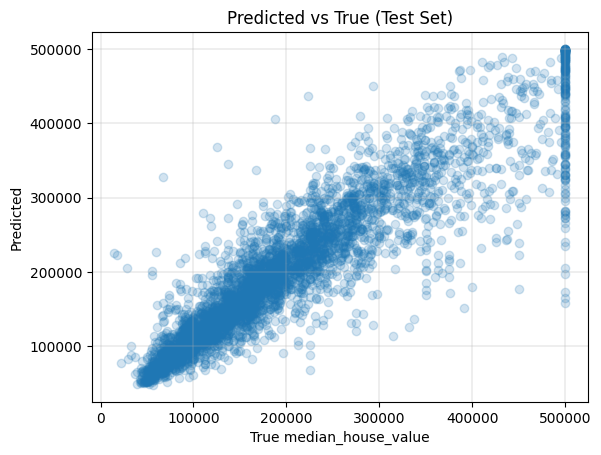

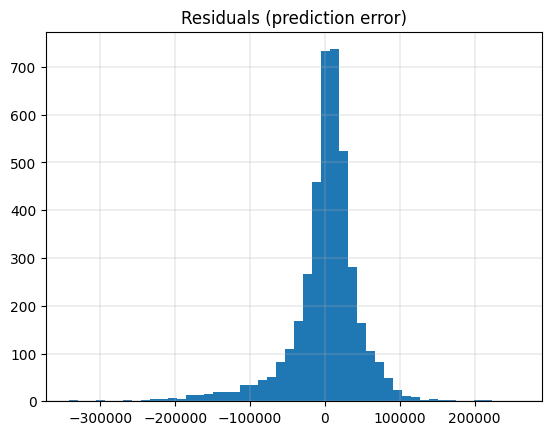

In [10]:
best_pipe = grid2.best_estimator_
pred = best_pipe.predict(housing_test)

plt.figure()
plt.scatter(test_labels, pred, alpha=0.2)
plt.xlabel("True median_house_value")
plt.ylabel("Predicted")
plt.title("Predicted vs True (Test Set)")
plt.grid(True, linewidth=0.3)
plt.show()

plt.figure()
errors = pred - test_labels
plt.hist(errors, bins=50)
plt.title("Residuals (prediction error)")
plt.grid(True, linewidth=0.3)
plt.show()
